# Travel Time Tomography

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/UW-geophysics-edu/ess-412-512-intro2seismology/blob/main/notebooks/travel_time_tomography_iterative_pykonal.ipynb)

**Learning Objectives:**
- Solve the Eikonal equation for travel times
- Perform iterative non-linear tomography
- Invert travel time residuals for velocity perturbations
- Assess model resolution with checkerboard tests

**Prerequisites:** Inverse theory, Optimization

**Reference:** Shearer, Chapter 5 (Travel Time Tomography)

**Notebook Outline:**
- [Setup: imports + helper functions](#Setup-imports-+-helper-functions)
- [A. Straight-ray travel-time tomography (block model)](#A-Straight-ray-travel-time-tomography-block-model)
  - [A1. Discretize the Earth into cells](#A1-Discretize-the-Earth-into-cells)
- [A2. Define a synthetic “true” model](#A2-Define-a-synthetic-“true”-model)
- [A3. Acquisition geometry: sources & receivers](#A3-Acquisition-geometry-sources-&-receivers)
- [A4. Build the tomography matrix \(G\)](#A4-Build-the-tomography-matrix-\G\)
- [A5. Generate synthetic travel-time residuals](#A5-Generate-synthetic-travel-time-residuals)
- [A6. Invert with damping (minimum-norm)](#A6-Invert-with-damping-minimum-norm)
- [A7. Invert with smoothness (minimum-roughness)](#A7-Invert-with-smoothness-minimum-roughness)
- [A8. Coverage map (resolution intuition)](#A8-Coverage-map-resolution-intuition)
- [A9. Checkerboard (resolution) test](#A9-Checkerboard-resolution-test)
- [Learning goals for Part B](#Learning-goals-for-Part-B)
- [B1. Define a more “realistic” velocity model in x–z](#B1-Define-a-more-“realistic”-velocity-model-in-x–z)
- [B2. Geometry: sources at depth, receivers at surface](#B2-Geometry-sources-at-depth,-receivers-at-surface)
- [B3. Forward modeling with PyKonal: travel times + ray tracing](#B3-Forward-modeling-with-PyKonal-travel-times-+-ray-tracing)
- [B4. Build \(G\) from bent rays (2-D cell model)](#B4-Build-\G\-from-bent-rays-2-D-cell-model)
- [B5. Iterative update scheme](#B5-Iterative-update-scheme)
- [B6. Compare ray paths: reference vs true](#B6-Compare-ray-paths-reference-vs-true)
- [B7. Exercise: run iterative bent-ray tomography](#B7-Exercise-run-iterative-bent-ray-tomography)
- [B8. Visualize the recovered update and the updated velocity](#B8-Visualize-the-recovered-update-and-the-updated-velocity)
- [B9. Compare ray paths before/after inversion](#B9-Compare-ray-paths-before/after-inversion)
- [Wrap-up: what you should be able to explain (verbally)](#Wrap-up-what-you-should-be-able-to-explain-verbally)
- [Optional extensions (good homework or grad add-on)](#Optional-extensions-good-homework-or-grad-add-on)

---
```{note}
```


In [ ]:
# Install dependencies (for Google Colab or missing packages)
import sys

# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except:
    IN_COLAB = False
    print("Running in local environment")

# Install required packages if needed
required_packages = {
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'scipy': 'scipy',
    'obspy': 'obspy'
}

missing_packages = []
for package, pip_name in required_packages.items():
    try:
        __import__(package)
        print(f"✓ {package} is already installed")
    except ImportError:
        missing_packages.append(pip_name)
        print(f"✗ {package} not found")

if missing_packages:
    print(f"\nInstalling missing packages: {', '.join(missing_packages)}")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing_packages)
    print("✓ Installation complete!")
else:
    print("\n✓ All required packages are installed!")

## Setup: imports + helper functions

We will use:
- **NumPy/SciPy** for linear algebra and sparse matrices
- **Matplotlib** for visualization
- **PyKonal** for eikonal-based travel times + ray tracing (for the *iterative* part)

> If you run this in Colab, you may need to install pykonal first.

In [1]:
# If needed (e.g., on Colab), uncomment:
# !pip -q install pykonal

import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.sparse.linalg import lsqr

np.random.seed(7)

In [2]:
def cell_index(ix, iy, nx, ny):
    return iy * nx + ix

def plot_model(m, nx, ny, title="", cmap="seismic", vlim=None):
    M = m.reshape(ny, nx)
    plt.figure(figsize=(6,4))
    if vlim is None:
        vmax = np.max(np.abs(M)) + 1e-12
        vlim = (-vmax, vmax)
    plt.imshow(M, origin="lower", cmap=cmap, vmin=vlim[0], vmax=vlim[1],
               extent=(0,1,0,1), aspect="auto")
    plt.colorbar(label="model value")
    plt.title(title)
    plt.xlabel("x"); plt.ylabel("y")
    plt.tight_layout()

def sample_points_on_segment(p0, p1, n=1200):
    t = np.linspace(0.0, 1.0, n)
    return (1-t)[:,None]*p0 + t[:,None]*p1

## A. Straight-ray travel-time tomography (block model)

### A1. Discretize the Earth into cells
We use a 2-D unit square $[0,1]\times[0,1]$ split into $ n_x\times n_y$ cells.
The model is **slowness perturbation** per cell:

$$
\mathbf{m} = [\delta u_1,\dots,\delta u_M]^T
$$

In [3]:
nx, ny = 25, 20
nmodel = nx * ny

## A2. Define a synthetic “true” model

We choose a checkerboard because it makes resolution failures obvious.

> **Prediction:** Which parts of the checkerboard will be recovered best: near the center or near corners? Why?

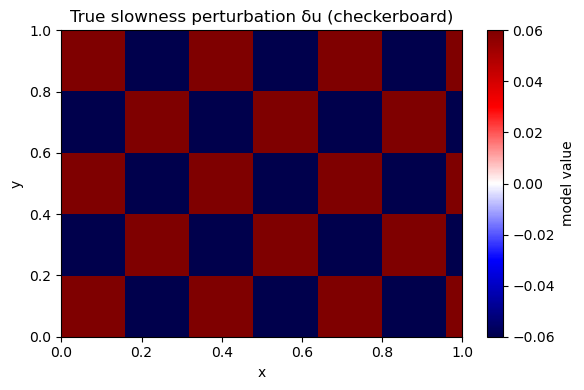

In [4]:
m_true = np.zeros(nmodel)
for iy in range(ny):
    for ix in range(nx):
        s = 1 if ((ix//4 + iy//4) % 2 == 0) else -1
        m_true[cell_index(ix, iy, nx, ny)] = 0.06 * s

plot_model(m_true, nx, ny, title="True slowness perturbation δu (checkerboard)")

## A3. Acquisition geometry: sources & receivers

We place sources at the bottom and receivers at the top to make a simple “regional” geometry.

> **Prediction:** With mostly near-vertical rays, will you resolve horizontal or vertical variations better?

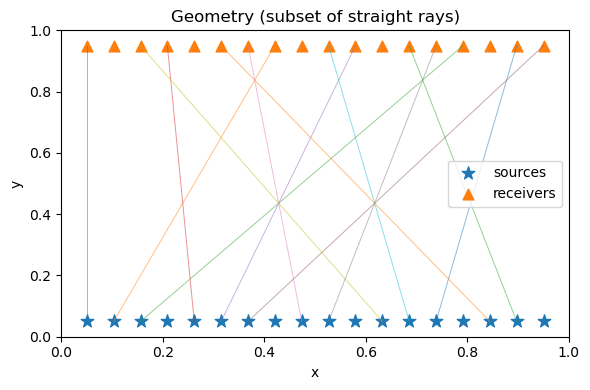

In [5]:
nrec = 18
nsrc = 18

receivers = np.column_stack([np.linspace(0.05, 0.95, nrec),
                             np.full(nrec, 0.95)])
sources = np.column_stack([np.linspace(0.05, 0.95, nsrc),
                           np.full(nsrc, 0.05)])

pairs = [(s, r) for s in range(nsrc) for r in range(nrec)]

plt.figure(figsize=(6,4))
plt.scatter(sources[:,0], sources[:,1], marker="*", s=90, label="sources")
plt.scatter(receivers[:,0], receivers[:,1], marker="^", s=60, label="receivers")

for (s, r) in pairs[::25]:
    p0, p1 = sources[s], receivers[r]
    plt.plot([p0[0], p1[0]], [p0[1], p1[1]], lw=0.7, alpha=0.5)

plt.legend()
plt.xlim(0,1); plt.ylim(0,1)
plt.xlabel("x"); plt.ylabel("y")
plt.title("Geometry (subset of straight rays)")
plt.tight_layout()

## A4. Build the tomography matrix \(G\)

For straight rays, \(G_{ij}\) is the **path length of ray i inside cell j**.

We build it by:
1. sampling many points along each ray segment
2. counting which cell each sample falls into
3. converting counts to approximate path length

In [6]:
def build_G_sampling(sources, receivers, pairs, nx, ny, npts=1600):
    dx = 1.0 / nx
    dy = 1.0 / ny

    rows, cols, vals = [], [], []

    for i, (s, r) in enumerate(pairs):
        p0, p1 = sources[s], receivers[r]
        pts = sample_points_on_segment(p0, p1, n=npts)

        x = np.clip(pts[:,0], 0.0, 1.0 - 1e-12)
        y = np.clip(pts[:,1], 0.0, 1.0 - 1e-12)

        ix = (x / dx).astype(int)
        iy = (y / dy).astype(int)

        Ltot = np.linalg.norm(p1 - p0)
        ds = Ltot / (npts - 1)

        cell_ids = iy * nx + ix
        uniq, counts = np.unique(cell_ids, return_counts=True)

        for cid, c in zip(uniq, counts):
            rows.append(i)
            cols.append(cid)
            vals.append(c * ds)

    return sparse.csr_matrix((vals, (rows, cols)),
                             shape=(len(pairs), nx*ny))

G = build_G_sampling(sources, receivers, pairs, nx, ny)
print("G shape:", G.shape, "nnz:", G.nnz)

G shape: (324, 500) nnz: 8344


## A5. Generate synthetic travel-time residuals

We compute:
$$
\mathbf{d} = G\,\mathbf{m}_{true} + \epsilon
$$

> Interpretation: if $\delta u>0$ (slower-than-reference), rays through that region arrive **late** (positive residual).

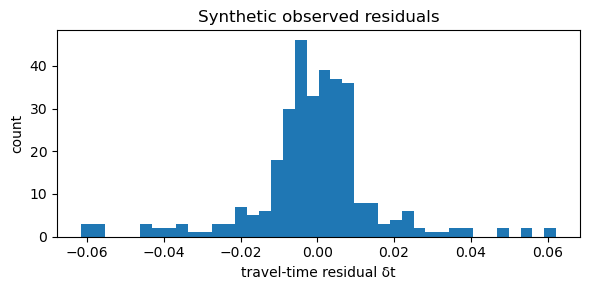

In [7]:
sigma = 0.002
d_clean = G @ m_true
d_obs = d_clean + sigma * np.random.randn(d_clean.size)

plt.figure(figsize=(6,3))
plt.hist(d_obs, bins=40)
plt.xlabel("travel-time residual δt")
plt.ylabel("count")
plt.title("Synthetic observed residuals")
plt.tight_layout()

## A6. Invert with damping (minimum-norm)

Solve:
$$
\min_m \|Gm-d\|^2 + \lambda^2\|m\|^2
$$

> **Prediction:** As $\lambda$ increases, what happens to the model amplitude? What happens to data fit?

λ=0.020  rms_misfit=0.0007  iters=228
λ=0.050  rms_misfit=0.0012  iters=100
λ=0.100  rms_misfit=0.0021  iters=56


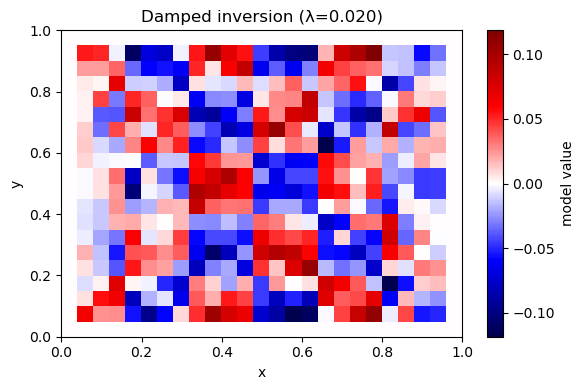

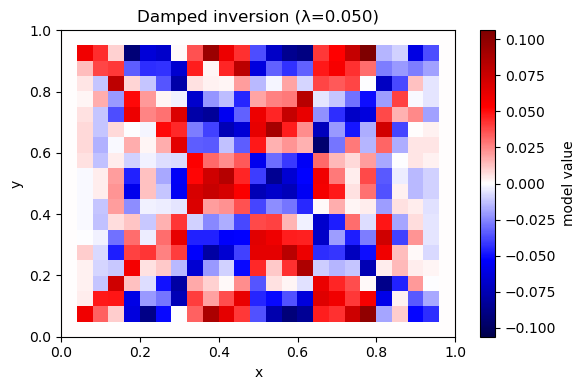

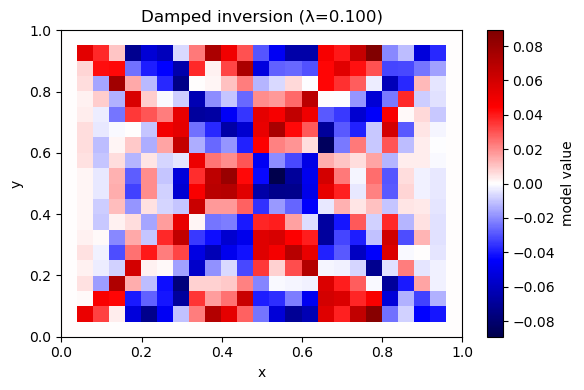

In [8]:
def invert_damped(G, d, lam):
    nmodel = G.shape[1]
    A = sparse.vstack([G, lam * sparse.eye(nmodel)], format="csr")
    b = np.concatenate([d, np.zeros(nmodel)])
    sol = lsqr(A, b, atol=1e-10, btol=1e-10, iter_lim=3000)
    return sol[0], sol

for lam in [0.02, 0.05, 0.1]:
    m_hat, info = invert_damped(G, d_obs, lam)
    rms = np.linalg.norm(G @ m_hat - d_obs) / np.sqrt(d_obs.size)
    print(f"λ={lam:.3f}  rms_misfit={rms:.4f}  iters={info[2]}")
    plot_model(m_hat, nx, ny, title=f"Damped inversion (λ={lam:.3f})")

## A7. Invert with smoothness (minimum-roughness)

Solve:
$$
\min_m \|Gm-d\|^2 + \lambda^2\|Lm\|^2
$$
where $L$ is a discrete Laplacian (cell minus neighbor average).

> **Prediction:** Compared to damping, what kind of artifacts should smoothness suppress?

λ=0.50  rms_misfit=0.0051  rough=0.0084  iters=295
λ=1.00  rms_misfit=0.0078  rough=0.0051  iters=322
λ=2.00  rms_misfit=0.0109  rough=0.0024  iters=355


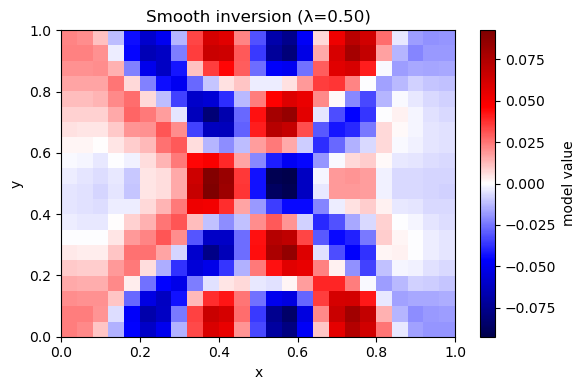

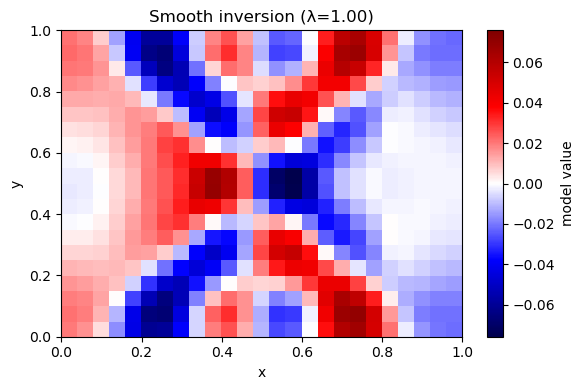

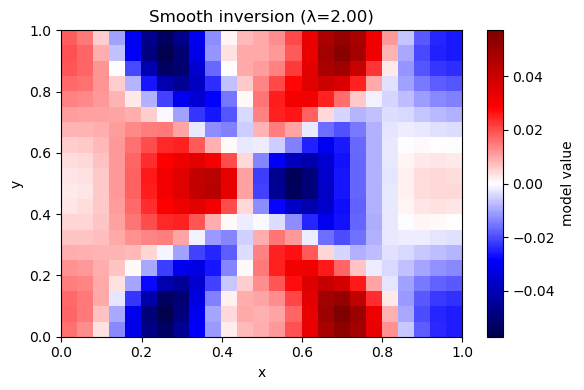

In [9]:
def laplacian_2d(nx, ny):
    rows, cols, vals = [], [], []
    eq = 0
    for iy in range(ny):
        for ix in range(nx):
            j = cell_index(ix, iy, nx, ny)
            neigh = []
            if ix > 0: neigh.append(cell_index(ix-1, iy, nx, ny))
            if ix < nx-1: neigh.append(cell_index(ix+1, iy, nx, ny))
            if iy > 0: neigh.append(cell_index(ix, iy-1, nx, ny))
            if iy < ny-1: neigh.append(cell_index(ix, iy+1, nx, ny))

            rows.append(eq); cols.append(j); vals.append(-1.0)
            for k in neigh:
                rows.append(eq); cols.append(k); vals.append(1/len(neigh))
            eq += 1
    return sparse.csr_matrix((vals, (rows, cols)), shape=(nx*ny, nx*ny))

L = laplacian_2d(nx, ny)

def invert_smooth(G, d, lam, L):
    A = sparse.vstack([G, lam * L], format="csr")
    b = np.concatenate([d, np.zeros(L.shape[0])])
    sol = lsqr(A, b, atol=1e-10, btol=1e-10, iter_lim=5000)
    return sol[0], sol

for lam in [0.5, 1.0, 2.0]:
    m_hat, info = invert_smooth(G, d_obs, lam, L)
    rms = np.linalg.norm(G @ m_hat - d_obs) / np.sqrt(d_obs.size)
    rough = np.linalg.norm(L @ m_hat) / np.sqrt(m_hat.size)
    print(f"λ={lam:.2f}  rms_misfit={rms:.4f}  rough={rough:.4f}  iters={info[2]}")
    plot_model(m_hat, nx, ny, title=f"Smooth inversion (λ={lam:.2f})")

## A8. Coverage map (resolution intuition)

Cells with low coverage are weakly constrained and get “filled in” by regularization.

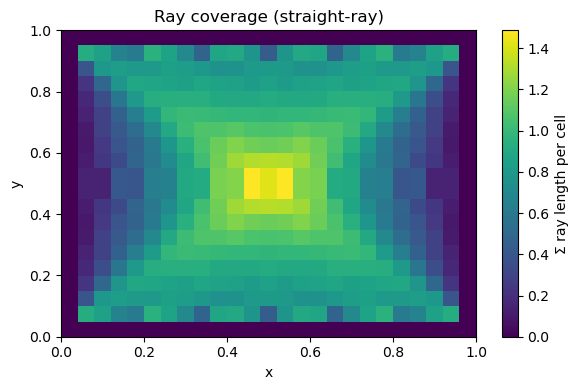

In [10]:
coverage = np.array(G.sum(axis=0)).ravel()

plt.figure(figsize=(6,4))
plt.imshow(coverage.reshape(ny, nx), origin="lower", extent=(0,1,0,1), aspect="auto")
plt.colorbar(label="Σ ray length per cell")
plt.title("Ray coverage (straight-ray)")
plt.xlabel("x"); plt.ylabel("y")
plt.tight_layout()

## A9. Checkerboard (resolution) test

Use **noise-free** data to isolate the effect of geometry + regularization.

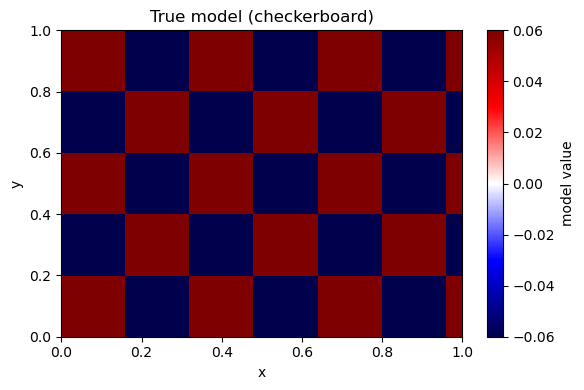

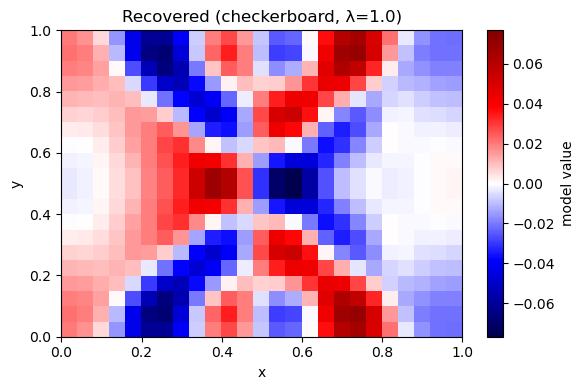

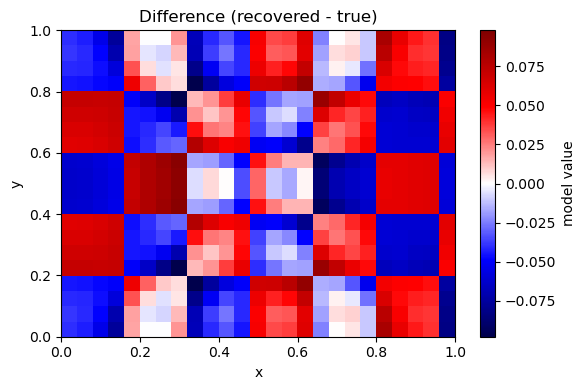

In [11]:
lam = 1.0
m_rec, _ = invert_smooth(G, d_clean, lam, L)

plot_model(m_true, nx, ny, title="True model (checkerboard)")
plot_model(m_rec, nx, ny, title=f"Recovered (checkerboard, λ={lam})")
plot_model(m_rec - m_true, nx, ny, title="Difference (recovered - true)")

# B. Iterative bent-ray tomography (PyKonal)

Straight-ray tomography assumes rays do **not** change as the model updates.
But in reality:
- rays bend toward **faster** regions (lower slowness)
- strong anomalies can invalidate straight-ray assumptions

## Learning goals for Part B
1. Use PyKonal to compute travel times in a heterogeneous velocity model.
2. Trace rays from receivers back through \(\nabla T\).
3. Build \(G\) from **bent ray paths**.
4. Implement a simple iterative scheme (re-linearization):
   - start from a smooth reference model
   - compute predicted times and residuals
   - invert for $\delta u$
   - update the model
   - re-trace rays

> **Prediction:** When rays bend around a slow anomaly, will the recovered anomaly in straight-ray inversion appear too broad, too narrow, or shifted?

## B1. Define a more “realistic” velocity model in x–z

We switch to an x–z domain (depth increasing downward) to resemble crustal tomography.

We will:
- define a background increasing velocity with depth
- add a low-velocity basin and a high-velocity body
- place sources at depth and receivers at the surface

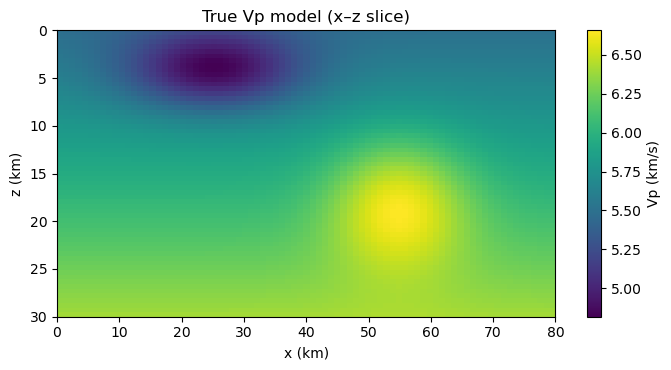

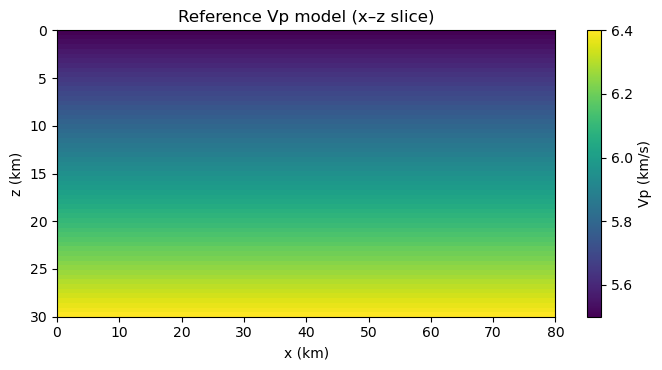

In [12]:
try:
    import pykonal
except Exception as e:
    raise ImportError("PyKonal is required for Part B. Install with `pip install pykonal`.") from e

# Grid (km units)
nx3, ny3, nz3 = 81, 3, 61
x = np.linspace(0.0, 80.0, nx3)
y = np.linspace(0.0, 2.0, ny3)     # thin in y
z = np.linspace(0.0, 30.0, nz3)    # depth (km), z=0 surface

X, Y, Z = np.meshgrid(x, y, z, indexing="ij")

# Background velocity: increases with depth
vp0 = 5.5 + 0.03 * Z  # km/s

# Low-velocity basin (near surface)
basin = -0.8 * np.exp(-((X-25.0)**2/(2*10.0**2) + (Z-4.0)**2/(2*3.0**2)))

# High-velocity body (deeper)
hv = +0.6 * np.exp(-((X-55.0)**2/(2*8.0**2) + (Z-18.0)**2/(2*5.0**2)))

vp_true = np.clip(vp0 + basin + hv, 3.0, None)
vp_ref  = vp0.copy()

def show_vslice(v, title):
    midy = ny3//2
    plt.figure(figsize=(7,3.8))
    plt.imshow(v[:,midy,:].T, origin="upper",
               extent=(x.min(), x.max(), z.max(), z.min()),
               aspect="auto")
    plt.colorbar(label="Vp (km/s)")
    plt.xlabel("x (km)"); plt.ylabel("z (km)")
    plt.title(title)
    plt.tight_layout()

show_vslice(vp_true, "True Vp model (x–z slice)")
show_vslice(vp_ref,  "Reference Vp model (x–z slice)")

## B2. Geometry: sources at depth, receivers at surface

We simulate **direct P** travel times:
- receivers at z=0 km
- sources distributed at 8–20 km depth

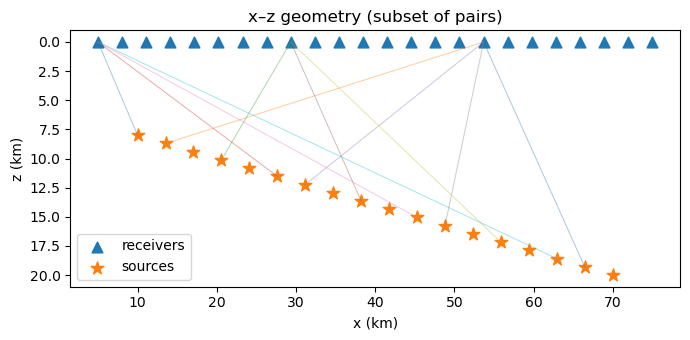

In [13]:
nrecB = 24
nsrcB = 18

rec_x = np.linspace(5.0, 75.0, nrecB)
src_x = np.linspace(10.0, 70.0, nsrcB)

receivers_B = np.column_stack([rec_x, np.full(nrecB, 1.0), np.zeros(nrecB)])  # y=1 km, z=0
src_z = np.linspace(8.0, 20.0, nsrcB)
sources_B = np.column_stack([src_x, np.full(nsrcB, 1.0), src_z])

pairs_B = [(s, r) for s in range(nsrcB) for r in range(nrecB)]

plt.figure(figsize=(7,3.5))
plt.scatter(receivers_B[:,0], receivers_B[:,2], marker="^", s=60, label="receivers")
plt.scatter(sources_B[:,0],   sources_B[:,2], marker="*", s=90, label="sources")
for (s, r) in pairs_B[::40]:
    p0, p1 = sources_B[s], receivers_B[r]
    plt.plot([p0[0], p1[0]], [p0[2], p1[2]], lw=0.7, alpha=0.4)
plt.gca().invert_yaxis()
plt.xlabel("x (km)"); plt.ylabel("z (km)")
plt.title("x–z geometry (subset of pairs)")
plt.legend()
plt.tight_layout()

## B3. Forward modeling with PyKonal: travel times + ray tracing

For each **source**:
1. Solve the eikonal equation for travel time field \(T\)
2. For each receiver, trace a ray following \(-\nabla T\)

We generate "observed" travel times in the **true** model.

In [14]:
def solve_times_and_rays(vp, sources, receivers, pairs, x, y, z):
    solver = pykonal.EikonalSolver(coord_sys='cartesian')
    solver.velocity.min_coords = (x.min(), y.min(), z.min())
    solver.velocity.node_intervals = (x[1]-x[0], y[1]-y[0], z[1]-z[0])
    solver.velocity.npts = (len(x), len(y), len(z))
    solver.velocity.values = vp.astype(np.float64)

    t_pred = np.zeros(len(pairs), dtype=float)
    rays = [None] * len(pairs)

    by_source = {}
    for i,(s,r) in enumerate(pairs):
        by_source.setdefault(s, []).append((i,r))

    for s, idx_list in by_source.items():
        src = sources[s]
        solver.traveltime.values[:] = np.nan
        solver.traveltime.is_outdated = True
        solver.source_loc = tuple(src.tolist())
        solver.solve()

        tracer = pykonal.RayTracer(coord_sys='cartesian')
        tracer.traveltime = solver.traveltime

        for (i, r) in idx_list:
            rec = receivers[r]
            t_pred[i] = solver.traveltime.value(tuple(rec.tolist()))
            tracer.receiver_loc = tuple(rec.tolist())
            rays[i] = np.array(tracer.trace_ray())
    return t_pred, rays

t_obs, rays_true = solve_times_and_rays(vp_true, sources_B, receivers_B, pairs_B, x, y, z)
print("t_obs range (s):", float(t_obs.min()), float(t_obs.max()))

AttributeError: 'pykonal.fields.ScalarField3D' object has no attribute 'is_outdated'

## B4. Build \(G\) from bent rays (2-D cell model)

We invert a 2-D \((x,z)\) slowness perturbation model (cells):
- model size = \((n_x-1)\times(n_z-1)\)

We build \(G\) by summing segment lengths into the cell that segment midpoints fall into.

In [ ]:
def build_G_from_rays_2d(rays, x, z):
    # 2-D cells (x,z), collapse y
    nx = len(x)
    nz = len(z)
    dx = x[1]-x[0]
    dz = z[1]-z[0]

    nxc = nx - 1
    nzc = nz - 1

    rows, cols, vals = [], [], []

    for i, ray in enumerate(rays):
        if ray is None or len(ray) < 2:
            continue

        p = ray
        seg = p[1:] - p[:-1]
        segL = np.linalg.norm(seg, axis=1)
        mid = 0.5*(p[1:] + p[:-1])

        ix = np.clip(((mid[:,0] - x.min())/dx).astype(int), 0, nxc-1)
        iz = np.clip(((mid[:,2] - z.min())/dz).astype(int), 0, nzc-1)

        cid = iz * nxc + ix

        order = np.argsort(cid)
        cid_s = cid[order]
        L_s = segL[order]

        start = 0
        while start < len(cid_s):
            end = start + 1
            while end < len(cid_s) and cid_s[end] == cid_s[start]:
                end += 1
            rows.append(i)
            cols.append(int(cid_s[start]))
            vals.append(float(L_s[start:end].sum()))
            start = end

    return sparse.csr_matrix((vals, (rows, cols)), shape=(len(rays), nxc*nzc))

# Rays in reference model (iteration 0)
t_ref0, rays_ref0 = solve_times_and_rays(vp_ref, sources_B, receivers_B, pairs_B, x, y, z)
G0 = build_G_from_rays_2d(rays_ref0, x, z)

print("G0 shape:", G0.shape, "nnz:", G0.nnz)

## B5. Iterative update scheme

At iteration $k$:
- compute $t^{pred}(u^{(k)})$
- residual $d^{(k)} = t^{obs} - t^{pred}$
- build $G^{(k)}$ from rays traced in $u^{(k)}$
- solve damped LS for $\delta u^{(k)}$
- update slowness: $u^{(k+1)} = u^{(k)} + \alpha\,\delta u^{(k)}$

We apply $\delta u(x,z)$ uniformly across the thin y dimension.

In [ ]:
def invert_damped_sparse(G, d, lam):
    nmodel = G.shape[1]
    A = sparse.vstack([G, lam*sparse.eye(nmodel)], format="csr")
    b = np.concatenate([d, np.zeros(nmodel)])
    sol = lsqr(A, b, atol=1e-10, btol=1e-10, iter_lim=5000)
    return sol[0], sol

def apply_du_2d_to_3d(vp, du2d, x, z):
    # vp is on nodes (nx,ny,nz); du2d is on 2-D cells (nxc*nzc)
    nx, ny, nz = vp.shape
    nxc, nzc = len(x)-1, len(z)-1
    du_cells = du2d.reshape(nzc, nxc).T  # (nxc, nzc)

    u = 1.0 / vp
    # node-wise DU by assigning each node to nearest "below-left" cell
    ix = np.clip(np.arange(nx), 0, nxc-1)
    iz = np.clip(np.arange(nz), 0, nzc-1)
    DU = du_cells[ix[:,None], iz[None,:]]  # (nx, nz)
    DU3 = DU[:,None,:] * np.ones((1, ny, 1))

    u_new = u + DU3
    vp_new = 1.0 / np.clip(u_new, 1e-6, None)
    return vp_new

def show_du2d(du2d, x, z, title):
    nxc, nzc = len(x)-1, len(z)-1
    DU = du2d.reshape(nzc, nxc).T  # (nxc, nzc)
    plt.figure(figsize=(7,3.8))
    vmax = np.max(np.abs(DU)) + 1e-12
    plt.imshow(DU.T, origin="upper",
               extent=(x.min(), x.max(), z.max(), z.min()),
               aspect="auto", cmap="seismic", vmin=-vmax, vmax=vmax)
    plt.colorbar(label="δu (s/km)")
    plt.xlabel("x (km)"); plt.ylabel("z (km)")
    plt.title(title)
    plt.tight_layout()

## B6. Compare ray paths: reference vs true

> Rays bend toward **faster** regions (lower slowness).  
In a low-velocity basin, rays tend to skirt the slowest part if alternative faster paths exist.

In [ ]:
def plot_rays_xz(rays, title, nplot=14):
    plt.figure(figsize=(7,3.8))
    plt.xlim(x.min(), x.max()); plt.ylim(z.max(), z.min())
    plt.xlabel("x (km)"); plt.ylabel("z (km)")
    plt.title(title)

    idx = np.linspace(0, len(rays)-1, nplot).astype(int)
    for i in idx:
        ray = rays[i]
        if ray is None:
            continue
        plt.plot(ray[:,0], ray[:,2], lw=1.0, alpha=0.8)

    plt.scatter(receivers_B[:,0], receivers_B[:,2], marker="^", s=30)
    plt.scatter(sources_B[:,0], sources_B[:,2], marker="*", s=45)
    plt.gca().invert_yaxis()
    plt.tight_layout()

plot_rays_xz(rays_ref0, "Rays traced in reference model (iteration 0)")
plot_rays_xz(rays_true, "Rays traced in true model (for comparison)")

## B7. Exercise: run iterative bent-ray tomography

Tune:
- `lam_B` (damping)
- `alpha` (step length)
- `niter` (number of iterations)

> If you see instability (misfit spikes), reduce `alpha` first.

In [ ]:
niter = 5
lam_B = 0.02
alpha = 0.7

vp_k = vp_ref.copy()
history = []

for k in range(niter):
    t_pred_k, rays_k = solve_times_and_rays(vp_k, sources_B, receivers_B, pairs_B, x, y, z)
    d_k = t_obs - t_pred_k

    rms = np.linalg.norm(d_k) / np.sqrt(d_k.size)
    print(f"iter {k}: rms residual (s) = {rms:.4f}")

    Gk = build_G_from_rays_2d(rays_k, x, z)
    du2d, info = invert_damped_sparse(Gk, d_k, lam_B)

    vp_k = apply_du_2d_to_3d(vp_k, alpha*du2d, x, z)

    history.append((rms, du2d, rays_k))

plt.figure(figsize=(6,3))
plt.plot([h[0] for h in history], marker="o")
plt.xlabel("iteration")
plt.ylabel("RMS residual (s)")
plt.title("Iterative bent-ray tomography: misfit evolution")
plt.tight_layout()

## B8. Visualize the recovered update and the updated velocity

We plot:
- recovered $\delta u(x,z)$ at the last iteration
- updated $V_p$ slice

> **Interpretation:** Compare recovered $\delta u$ location with the true basin/body locations in the velocity figure at the top of Part B.

In [ ]:
rms_last, du_last, rays_last = history[-1]
show_du2d(du_last, x, z, title="Recovered δu (last iteration, 2-D cells)")
show_vslice(vp_k, "Updated Vp after iterations (x–z slice)")

## B9. Compare ray paths before/after inversion

This shows the feedback loop:
**model → rays → G → update → model**.

In [ ]:
plot_rays_xz(history[0][2], "Rays at iteration 0 (reference)")
plot_rays_xz(rays_last,       "Rays at final iteration (updated model)")

## Wrap-up: what you should be able to explain (verbally)

1. What exactly is in $\mathbf{d}$, $\mathbf{m}$, $\mathbf{G}$?
2. Why does limited ray geometry create null space and smearing?
3. What does damping assume about the Earth?
4. What makes bent-ray tomography nonlinear?
5. Which tuning knobs control stability vs resolution: $\lambda$, $\alpha$, geometry?

---

## Optional extensions (good homework or grad add-on)
- Add origin-time unknowns (one per source) into the inversion.
- Add station terms (one per receiver).
- Replace damping with smoothness (2-D Laplacian) in Part B.
- Run a checkerboard test using PyKonal-generated “observations” and invert from a smooth reference.